## Load Dataset

In [6]:
import sys

sys.path.append('.')

import pandas as pd

import numpy as np

import math

from sklearn.cluster import KMeans

from scipy.spatial.distance import euclidean


from utils.kmeans_evaluation import evaluate_kmeans_overlap

from structures.grid import Grid

from structures.r_tree_analyzer import RTreeSpatialAnalyzer

%matplotlib inline

import matplotlib.pyplot as plt

%matplotlib inline

import matplotlib.pyplot as plt

In [7]:
csv_data = pd.read_csv("datasets/skewed_coords.csv")
# latitudes = csv_data["latitude"]
# longitudes = csv_data["longitude"]
latitudes = csv_data["latitude"]
longitudes = csv_data["longitude"]

maxLatitude = latitudes.max()
minLatitude = latitudes.min()
minLatitude = math.floor(minLatitude)
maxLatitude = math.ceil(maxLatitude)

maxLongitude = longitudes.max()
maxLongitude = math.ceil(maxLongitude)

minLongtitude = longitudes.min()
minLongtitude = math.floor(minLongtitude)

points_array = np.column_stack((longitudes, latitudes))
# initiate KMEANS
kmeans_data = csv_data[["latitude", "longitude"]].to_numpy()


## KMEANS Evaluation

In [8]:
overlap_score, labels, centers, radii = evaluate_kmeans_overlap(
    kmeans_data, n_clusters=7
)
print("KMEANS Score:", overlap_score)

KMEANS Score: 368.6038868055136


## Grid Evalution

In [10]:
grid = Grid(
        xmin=minLongtitude, ymin=minLatitude, xmax=maxLongitude, ymax=maxLatitude, m=20
    )
    # assign points to grid
grid.fit(zip(csv_data["longitude"], csv_data["latitude"]))
    
print(f"Grid Score: {grid.compute_grid_overlap()}")

Grid Score: 57.3390348388378


In [11]:
print(grid.get_cluster_list())

[((-7.6, -1.7999999999999998), 0.39433416062637705), ((-7.6, -0.19999999999999996), 0.3954001224965922), ((-7.6, 0.20000000000000018), 0.23022244152544097), ((-7.6, 0.6000000000000005), 0.19436137342186754), ((-7.6, 1.0000000000000004), 0.38435384670947365), ((-7.6, 1.4000000000000004), 0.32563490390506505), ((-7.6, 1.8000000000000003), 0.4000024859469802), ((-7.6, 2.2), 0.35909740862600664), ((-7.6, 2.6000000000000005), 0.23197164747536747), ((-6.800000000000001, -1.7999999999999998), 0.3567660208925518), ((-6.800000000000001, -1.3999999999999997), 0.12116251249337535), ((-6.800000000000001, -0.9999999999999998), 0.31660357062561634), ((-6.800000000000001, -0.5999999999999999), 0.3995279111135967), ((-6.800000000000001, -0.19999999999999996), 0.3872183720768176), ((-6.800000000000001, 0.20000000000000018), 0.39644675643274613), ((-6.800000000000001, 0.6000000000000005), 0.40045056391739514), ((-6.800000000000001, 1.0000000000000004), 0.4322557642050619), ((-6.800000000000001, 1.400000

## R Tree Evaluation

In [12]:
csv_file_path = "./datasets/skewed_coords.csv"
analyzer = RTreeSpatialAnalyzer()
if analyzer.load_data_from_csv(csv_file_path,required_cols=['latitude','longitude']):
    total_overlap = analyzer.compute_overlap()
    print(f"Total computed overlap area among circles: {total_overlap:.2f}")
    # analyzer.visualize()

R-tree built with 1000 entries.
Total computed overlap area among circles: 14411.45


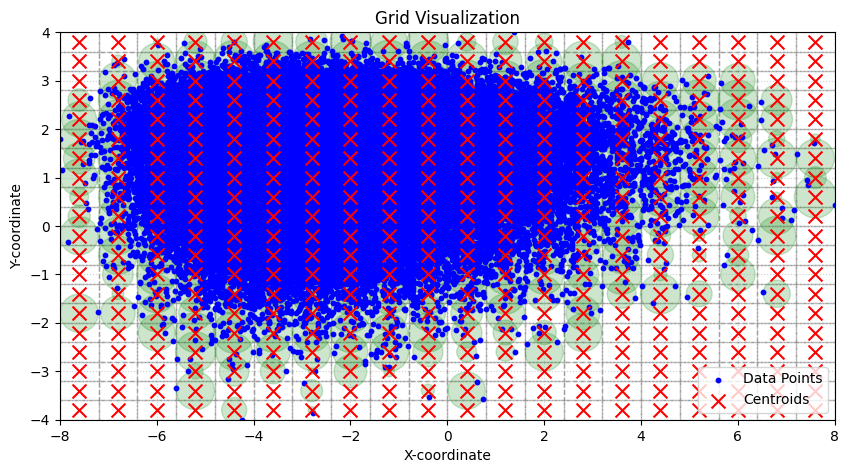

In [ ]:
grid.visualize_grid()

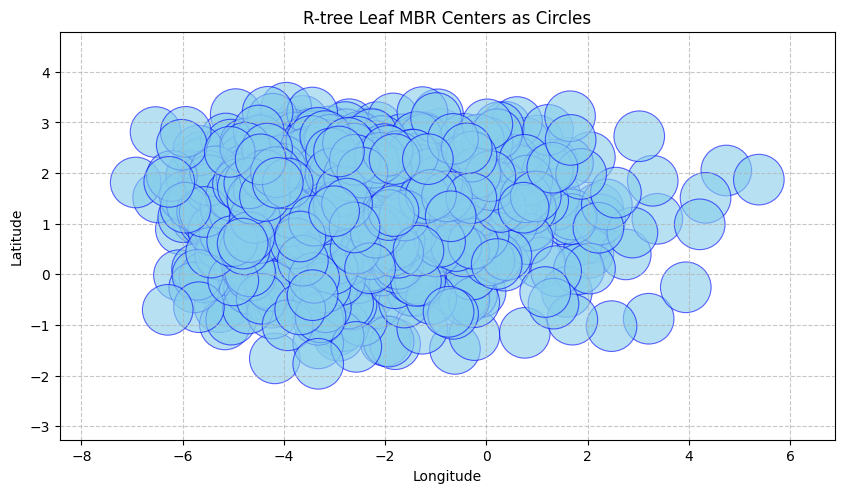

In [ ]:
analyzer.visualize()

In [ ]:
kmeans_overlap = overlap_score  
grid_overlap = grid.compute_grid_overlap()
# density_grid_overlap = density_grid.compute_grid_overlap()
r_tree_overlap = total_overlap

algorithm_details = [
    {
        "Algorithm": "KMEANS",
        "Overlap Score": kmeans_overlap,
        "Parameters": "n_clusters=7"
    },
    {
        "Algorithm": "Grid",
        "Overlap Score": grid_overlap,
        "Parameters": "m=20"
    },

    {
        "Algorithm": "R-Tree",
        "Overlap Score": r_tree_overlap,
        "Parameters": "-"
    }
]

import pandas as pd
comparison_df = pd.DataFrame(algorithm_details)
display(comparison_df)

,Algorithm,Overlap Score,Parameters
0,KMEANS,368.603887,n_clusters=7
1,Grid,57.339035,m=20
2,R-Tree,14411.450293,-


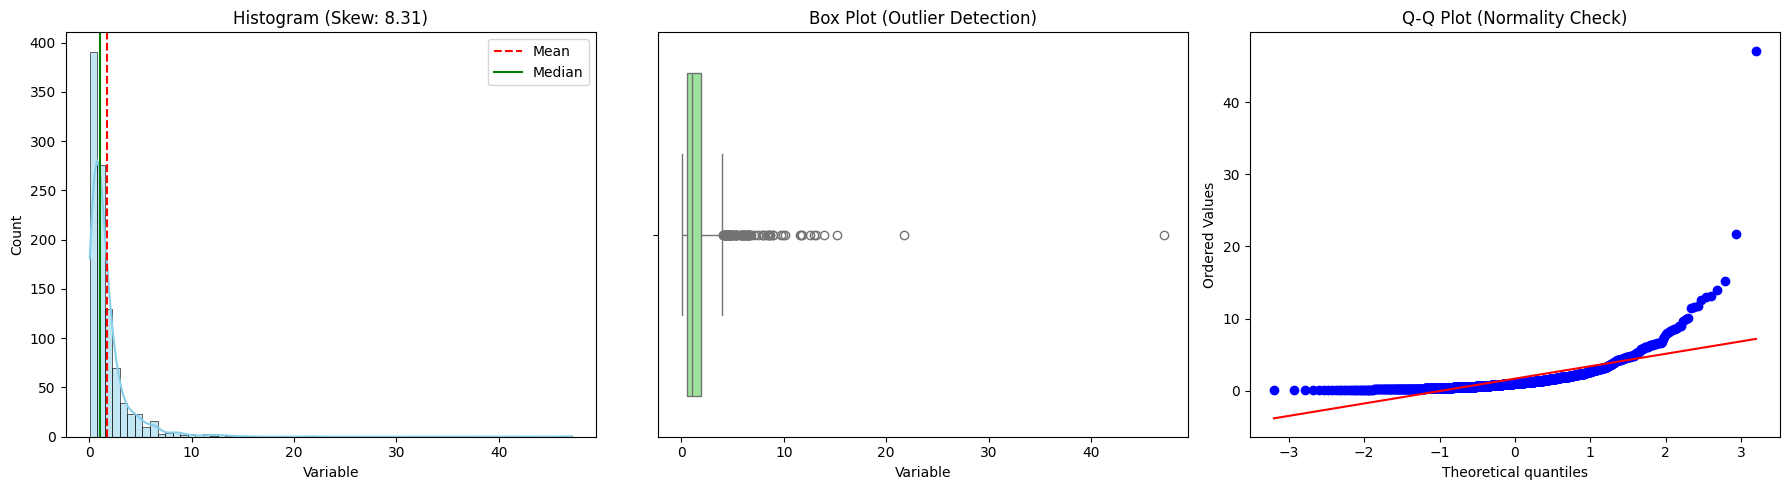

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generating a log-normal distribution (inherently right-skewed)
np.random.seed(42)
data = np.random.lognormal(mean=0, sigma=1, size=1000)
df = pd.DataFrame(data, columns=['Variable'])

# Calculate Skewness and Kurtosis
skew_val = df['Variable'].skew()
kurt_val = df['Variable'].kurt()

# Setup the plotting area
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram with KDE
sns.histplot(df['Variable'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f'Histogram (Skew: {skew_val:.2f})')
axes[0].axvline(df['Variable'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(df['Variable'].median(), color='green', linestyle='-', label='Median')
axes[0].legend()

# 2. Box Plot
sns.boxplot(x=df['Variable'], ax=axes[1], color='lightgreen')
axes[1].set_title('Box Plot (Outlier Detection)')

# 3. Probability Plot (Q-Q Plot)
stats.probplot(df['Variable'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()